## DIPm-TV simulation pipeline

| Scenario | Structure | Channels | Tilt range | Reference |
|---|---|---|---|---|
| **EDX** | Cube + sphere hole + ellipsoid hole | 3 (cube / ellipsoid / sphere) | −40 : 5 : +40  (17 proj.) | arXiv:2606.10547 |
| **EELS** | Hollow core-shell nanocube with pore | 2 (shell / core) | −70 : 17.5 : +70  (9 proj.) | arXiv:2606.10893 |

In [ ]:
import sys
sys.path.insert(0, '../../Src')

from radon import Radon3D
from dipm_tv import CNN3D, run_dipm_tv, preprocess_sinograms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
from scipy.ndimage import rotate as scipy_rotate
from skimage.metrics import structural_similarity as _skssim

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['image.cmap'] = 'gray'
print(f'Device: {DEVICE}')

INPUT_DEPTH = 32
THETA_REF   = np.arange(0, 180, 1)   # 180-projection reference (both scenarios)

# ── Custom colourmaps ──────────────────────────────────────────────────────
CMAP_MAGENTA = LinearSegmentedColormap.from_list('magenta', ['white', 'magenta'])

# ── EDX hyper-parameters  (arXiv:2606.10547) ──────────────────────────────
NUM_ITER_EDX      = 5000
LR_EDX            = 4e-4
NOISE_REG_EDX     = 0.04
LAMBDA_TV_EDX     = 1e-10
STD_INP_NOISE_EDX = 1. / 10.
LOSS_TYPE_EDX     = 'L2'
USE_AMP_EDX       = True
SAVE_EVERY_EDX    = 200
UD_FILTERS_EDX    = [16, 32, 64, 128, 256]   # 5-level encoder/decoder
SKIP_FILTERS_EDX  = [ 4,  8, 16,  32,  64]

# ── EELS hyper-parameters  (arXiv:2606.10893) ─────────────────────────────
NUM_ITER_EELS      = 1000
LR_EELS            = 4e-4
NOISE_REG_EELS     = 0.01
LAMBDA_TV_EELS     = 1e-10
STD_INP_NOISE_EELS = 1. / 10.
LOSS_TYPE_EELS     = 'L1'
USE_AMP_EELS       = False
SAVE_EVERY_EELS    = 100
UD_FILTERS_EELS    = [16, 32, 64, 128]   # 4-level encoder/decoder
SKIP_FILTERS_EELS  = [ 4,  8, 16,  32]

def build_net(nbr, ud_filters, skip_filters, device=DEVICE):
    """Build CNN3D for `nbr` output channels with the given encoder/decoder widths."""
    n = len(ud_filters)
    return CNN3D(
        nbr=nbr, input_shape=INPUT_DEPTH,
        down_filters=ud_filters, up_filters=ud_filters, skip_filters=skip_filters,
        down_kernels=(3,)*n, up_kernels=(3,)*n, skip_kernels=(1,)*n,
        up_mode='trilinear', pad_mode='reflect',
    ).to(device)

def _n(arr, sl):
    """Slice a (Y,X,Z) or (1,Y,X,Z) volume and normalise to [0,1]."""
    if torch.is_tensor(arr): arr = arr.detach().cpu().numpy()
    if arr.ndim == 4: arr = arr[0]
    x = arr[sl].astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

def embed_sino(sino_lim, theta_lim, n_angles=180):
    """Embed limited (Y, N_lim, det) sinogram → (Y, n_angles, det) with zeros at missing angles."""
    Y, _, W = sino_lim.shape
    out = np.zeros((Y, n_angles, W), dtype=np.float32)
    for i, th in enumerate(theta_lim.astype(int)):
        out[:, th, :] = sino_lim[:, i, :].cpu().numpy()
    return out

# ── Compact panel helpers ─────────────────────────────────────────────────

def _norm_perc(img, p_lo=1, p_hi=99):
    lo, hi = np.percentile(img, p_lo), np.percentile(img, p_hi)
    return np.clip((img - lo) / (hi - lo + 1e-9), 0, 1).astype(np.float32)

def _nrmse(ref, est):
    rng = float(np.max(ref) - np.min(ref))
    return float(np.sqrt(np.mean((ref - est) ** 2)) / (rng + 1e-9))

def _ssim(ref, est):
    return float(_skssim(_norm_perc(ref), _norm_perc(est), data_range=1.0))

def _get_sl(vol, axis, idx):
    """Extract a 2-D slice from a (Y,X,Z) volume or tensor."""
    if torch.is_tensor(vol): vol = vol.detach().cpu().numpy()
    if vol.ndim == 4: vol = vol[0]
    s = [slice(None)] * 3; s[axis] = idx
    return vol[tuple(s)].astype(np.float32)

def _rgb_red(v, p_hi=99):
    x = _norm_perc(v, 1, p_hi)
    return np.stack([x, np.zeros_like(x), np.zeros_like(x)], -1)

def _rgb_green(v, p_hi=99):
    x = _norm_perc(v, 1, p_hi)
    return np.stack([np.zeros_like(x), x, np.zeros_like(x)], -1)

def _rgb_blue(v, p_hi=99):
    x = _norm_perc(v, 1, p_hi)
    return np.stack([np.zeros_like(x), np.zeros_like(x), x], -1)

def _rgb_magenta(v, p_hi=99):
    x = _norm_perc(v, 1, p_hi)
    return np.stack([x, np.zeros_like(x), x], -1)

def _rgb_GB(v2, v3, p_hi=99):
    g = _norm_perc(v2, 1, p_hi); b = _norm_perc(v3, 1, p_hi)
    return np.stack([np.zeros_like(g), g, b], -1)

def panel_results(
    vol_lists, method_names, gt_list,
    rows,           # list of (label, rgb_fn(sl_vols, p_hi), gt_ch_indices)
    axis, slice_idx,
    perc=(1, 99), title='', figsize_per_cell=(3, 3), dpi=150,
):
    """
    One figure:  cols = methods,  rows = channel groups (RGB composites).
    vol_lists   : [[v0,v1,...], ...] one list per method
    gt_list     : [gt0, gt1, ...] one volume per channel, for NRMSE/SSIM
    rows        : [(label, rgb_fn, gt_ch_indices), ...]
                  rgb_fn(sl_vols, p_hi) → H×W×3 float  (sl_vols = pre-sliced list)
    """
    ncols, nrows = len(method_names), len(rows)
    fw, fh = figsize_per_cell
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(fw*ncols, fh*nrows), dpi=dpi)
    if nrows == 1: axes = axes[np.newaxis, :]
    if ncols == 1: axes = axes[:, np.newaxis]

    p_hi = perc[1]
    gt_sl = [[_get_sl(g, axis, slice_idx) for g in gt_list]]  # cache GT slices

    for c, (mname, vols) in enumerate(zip(method_names, vol_lists)):
        is_gt = (c == 0)
        sl_vols = [_get_sl(v, axis, slice_idx) for v in vols]

        for r, (row_lbl, rgb_fn, gt_chs) in enumerate(rows):
            ax = axes[r, c]
            ax.imshow(rgb_fn(sl_vols, p_hi), interpolation='nearest')
            ax.axis('off')

            if r == 0:
                ax.set_title(mname, fontsize=9, pad=5)
            ax.text(0.02, 0.97, row_lbl,
                    transform=ax.transAxes, ha='left', va='top',
                    fontsize=8, color='w',
                    bbox=dict(facecolor='k', alpha=0.4, edgecolor='none', pad=1.5))

            if not is_gt:
                nrms  = [_nrmse(gt_sl[0][i], sl_vols[i]) for i in gt_chs]
                ssims = [_ssim (gt_sl[0][i], sl_vols[i]) for i in gt_chs]
                ax.text(0.03, 0.05,
                        f'NRMSE {np.mean(nrms):.2f}  SSIM {np.mean(ssims):.2f}',
                        transform=ax.transAxes, fontsize=7, color='w')

    plt.subplots_adjust(wspace=0.04, hspace=0.04)
    if title:
        plt.suptitle(title, fontsize=9, y=1.01)
    plt.show()

def show_channels(gt_list, sirt_ref_list, sirt_lim_list, dipmtv, ch_names, slices, title):
    """Legacy per-channel 4-row comparison (kept for reference)."""
    rows = ['GT', 'SIRT ref (180 proj.)', 'SIRT limited', 'DIPm-TV']
    all_data = [gt_list, sirt_ref_list, sirt_lim_list,
                [dipmtv[i] for i in range(dipmtv.shape[0])]]
    for ch_idx, ch_name in enumerate(ch_names):
        fig, axes = plt.subplots(4, len(slices), figsize=(4.5*len(slices), 4*4))
        for r, (row_lbl, data_list) in enumerate(zip(rows, all_data)):
            for c, (sl, sl_lbl) in enumerate(slices):
                axes[r, c].imshow(_n(data_list[ch_idx], sl))
                axes[r, c].set_title(f'{row_lbl} — {sl_lbl}', fontsize=8)
                axes[r, c].axis('off')
        plt.suptitle(f'{title}\nChannel {ch_idx}: {ch_name}', fontsize=9)
        plt.tight_layout(); plt.show()

---
## A — EDX   |  Cube + sphere hole + ellipsoid hole  |  −40 : 5 : +40

### A.1  Build phantom
Volume shape `(Y, X, Z)` — **Y = tilt axis** (axis 0, depth),  **X** = beam direction at 0° tilt (axis 1),  **Z** = missing-wedge elongation direction (axis 2).

Cube + sphere hole + ellipsoid hole; sphere and ellipsoid features sit at **Y = 70**.

In [25]:
def paint_sphere_center(volume, yc, xc, zc, r, val):
    """Paint sphere in (Y, X, Z) volume.  Y=tilt axis, X=beam@0°, Z=MW direction."""
    Ny, Nx, Nz = volume.shape
    y0, y1 = max(int(yc-r), 0), min(int(yc+r+1), Ny)
    x0, x1 = max(int(xc-r), 0), min(int(xc+r+1), Nx)
    z0, z1 = max(int(zc-r), 0), min(int(zc+r+1), Nz)
    yy = np.arange(y0, y1)[:, None, None]
    xx = np.arange(x0, x1)[None, :, None]
    zz = np.arange(z0, z1)[None, None, :]
    volume[y0:y1, x0:x1, z0:z1][(yy-yc)**2 + (xx-xc)**2 + (zz-zc)**2 <= r**2] = val

def paint_ellipsoid_center(volume, yc, xc, zc, ry, rx, rz, val=1.0):
    """Paint ellipsoid in (Y, X, Z) volume; semi-axes (ry, rx, rz)."""
    Ny, Nx, Nz = volume.shape
    y0, y1 = max(int(np.floor(yc-ry)), 0), min(int(np.ceil(yc+ry))+1, Ny)
    x0, x1 = max(int(np.floor(xc-rx)), 0), min(int(np.ceil(xc+rx))+1, Nx)
    z0, z1 = max(int(np.floor(zc-rz)), 0), min(int(np.ceil(zc+rz))+1, Nz)
    yy, xx, zz = np.ogrid[y0:y1, x0:x1, z0:z1]
    mask = ((yy-yc)/ry)**2 + ((xx-xc)/rx)**2 + ((zz-zc)/rz)**2 <= 1.0
    volume[y0:y1, x0:x1, z0:z1][mask] = val

In [26]:
NY_EDX = NX_EDX = NZ_EDX = 160   # (Y, X, Z): Y=tilt axis, X=beam@0°, Z=MW elongation

XC_EDX = NX_EDX // 2           # X centre = 80
ZC_EDX = NZ_EDX // 2 + 6       # Z centre = 86  (offset in MW direction)
HALF   = 30                     # cube half-side
Y_FEAT = 70                     # Y-depth position of sphere and ellipsoid

data1_edx = np.zeros((NY_EDX, NX_EDX, NZ_EDX), dtype=np.float32)  # cube
data2_edx = np.zeros_like(data1_edx)                               # ellipsoid
data3_edx = np.zeros_like(data1_edx)                               # sphere

# Cube: full Y extent (tilt axis), centred at (XC_EDX, ZC_EDX) in the XZ plane
data1_edx[:, XC_EDX-HALF:XC_EDX+HALF, ZC_EDX-HALF:ZC_EDX+HALF] = 25.0

# Sphere hole at Y=Y_FEAT  (yc, xc, zc)
paint_sphere_center(data3_edx, Y_FEAT, XC_EDX-4,  ZC_EDX+15, r=9,  val=15.0)
paint_sphere_center(data1_edx, Y_FEAT, XC_EDX-4,  ZC_EDX+15, r=9,  val=0.0)

# Ellipsoid hole at Y=Y_FEAT  (thin in Y and Z, elongated in X)
paint_ellipsoid_center(data2_edx, Y_FEAT, XC_EDX, ZC_EDX-14, ry=6, rx=19, rz=6, val=20.0)
paint_ellipsoid_center(data1_edx, Y_FEAT, XC_EDX, ZC_EDX-14, ry=6, rx=19, rz=6, val=0.0)

Visualization: 

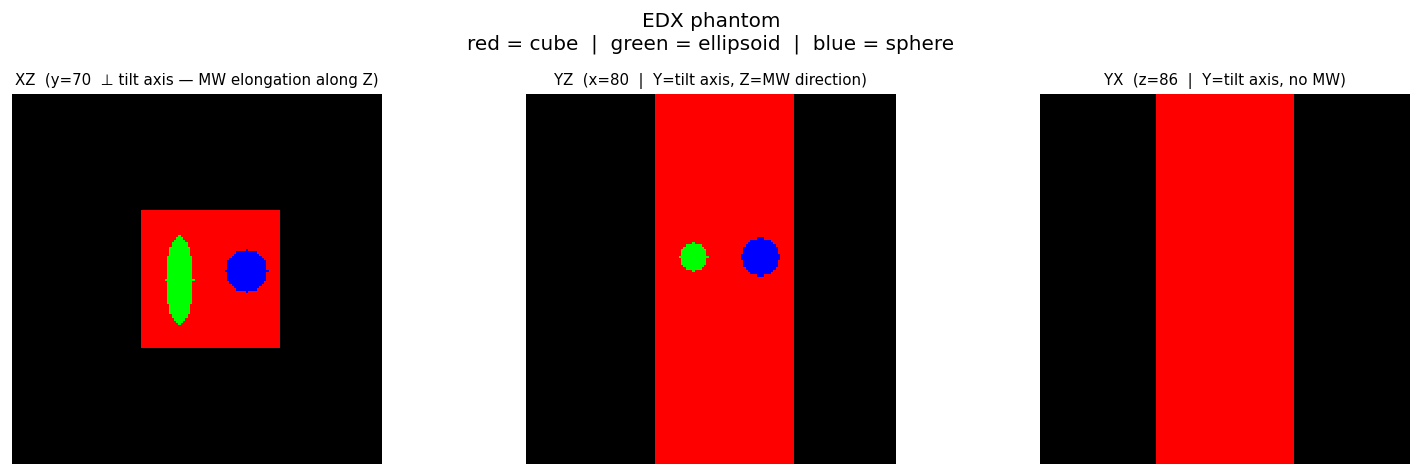

In [ ]:
# ── Visualise phantom (RGB composite) ────────────────────────────────
def norm01(x, lo, hi):
    return np.clip((x - lo) / (hi - lo + 1e-12), 0, 1).astype(np.float32)

def rgb_slice(sl, gamma=0.9):
    r = norm01(data1_edx[sl], 0, data1_edx.max())   # cube       -> R
    g = norm01(data2_edx[sl], 0, data2_edx.max())   # ellipsoid  -> G
    b = norm01(data3_edx[sl], 0, data3_edx.max())   # sphere     -> B
    rgb = np.stack([r, g, b], axis=-1)
    return np.clip(rgb, 0, 1) ** gamma

SLICES_EDX = [
    (np.s_[Y_FEAT, :, :],  f'XZ  (y={Y_FEAT}  ⊥ tilt axis — MW elongation along Z)'),
    (np.s_[:, XC_EDX, :],  f'YZ  (x={XC_EDX}  |  Y=tilt axis, Z=MW direction)'),
    (np.s_[:, :, ZC_EDX],  f'YX  (z={ZC_EDX}  |  Y=tilt axis, no MW)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=120)
for ax, (sl, lbl) in zip(axes, SLICES_EDX):
    ax.imshow(rgb_slice(sl), interpolation="nearest")
    ax.set_title(lbl, fontsize=9); ax.axis('off')
plt.suptitle('EDX phantom\nred = cube  |  green = ellipsoid  |  blue = sphere')
plt.tight_layout(); plt.show()

### A.2  Reference reconstruction  (0 : 1 : 179, 180 proj.)

SIRT reference EDX — 3 channels (180 proj.)...


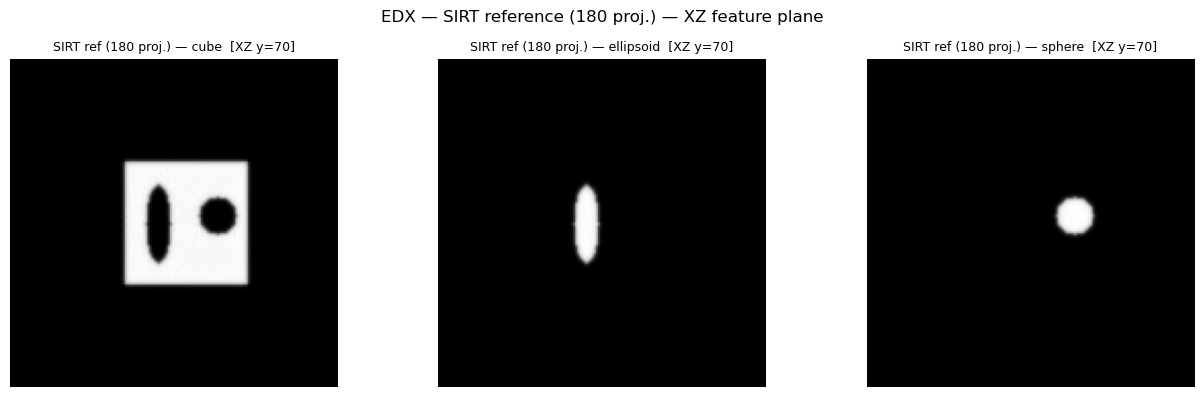

In [28]:
# Tensors for all 3 EDX channels
data1_edx_t = torch.from_numpy(data1_edx).float().to(DEVICE)
data2_edx_t = torch.from_numpy(data2_edx).float().to(DEVICE)
data3_edx_t = torch.from_numpy(data3_edx).float().to(DEVICE)
CH_NAMES_EDX = ['cube', 'ellipsoid', 'sphere']

rad_ref_edx = Radon3D(depth=NY_EDX, size=NX_EDX, angle=np.deg2rad(THETA_REF), device=DEVICE)
print('SIRT reference EDX — 3 channels (180 proj.)...')
with torch.no_grad():
    sirt_ref_edx_1 = rad_ref_edx.backward_sirt_ts(rad_ref_edx(data1_edx_t), num_iters=100)
    sirt_ref_edx_2 = rad_ref_edx.backward_sirt_ts(rad_ref_edx(data2_edx_t), num_iters=100)
    sirt_ref_edx_3 = rad_ref_edx.backward_sirt_ts(rad_ref_edx(data3_edx_t), num_iters=100)

sirt_ref_edx_list = [sirt_ref_edx_1, sirt_ref_edx_2, sirt_ref_edx_3]

# Visualise: one column per channel at the feature XZ plane
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, sirt_ref, ch_name in zip(axes, sirt_ref_edx_list, CH_NAMES_EDX):
    ax.imshow(_n(sirt_ref, np.s_[Y_FEAT, :, :]))
    ax.set_title(f'SIRT ref (180 proj.) — {ch_name}  [XZ y={Y_FEAT}]', fontsize=9)
    ax.axis('off')
plt.suptitle('EDX — SIRT reference (180 proj.) — XZ feature plane')
plt.tight_layout(); plt.show()

### A.3  Limited tilt series  (−40 : 5 : +40)  +  SIRT

In [ ]:
# 0-180 convention: physical_angle + 90
THETA_EDX = np.arange(90-40, 90+40+1, 5)   # [50, 55, ..., 130] → 17 proj.
print(f'Physical: {THETA_EDX[0]-90:.0f} : 5 : {THETA_EDX[-1]-90:.0f}   ({len(THETA_EDX)} proj.)')

rad_edx = Radon3D(depth=NY_EDX, size=NX_EDX, angle=np.deg2rad(THETA_EDX), device=DEVICE)

print('Computing sinograms and SIRT for 3 channels...')
with torch.no_grad():
    sino_edx_1 = rad_edx(data1_edx_t)   # cube
    sino_edx_2 = rad_edx(data2_edx_t)   # ellipsoid
    sino_edx_3 = rad_edx(data3_edx_t)   # sphere

    sirt_edx_1 = rad_edx.backward_sirt_ts(sino_edx_1, num_iters=100)
    sirt_edx_2 = rad_edx.backward_sirt_ts(sino_edx_2, num_iters=100)
    sirt_edx_3 = rad_edx.backward_sirt_ts(sino_edx_3, num_iters=100)

sirt_edx_list = [sirt_edx_1, sirt_edx_2, sirt_edx_3]

# ── GT sinograms for MW comparison ────────────────────────────────
print('Computing full-range sinograms for MW visualisation...')
with torch.no_grad():
    sino_gt_edx_1 = rad_ref_edx(data1_edx_t)   # (Y=160, 180, det_X=160)
    sino_gt_edx_2 = rad_ref_edx(data2_edx_t)
    sino_gt_edx_3 = rad_ref_edx(data3_edx_t)

sino_emb_edx = [embed_sino(s, THETA_EDX) for s in [sino_edx_1, sino_edx_2, sino_edx_3]]

# ── Sinogram: GT vs MW for each channel at Y_FEAT ────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 11))
for ch_idx, (ch_name, sino_gt, sino_emb) in enumerate(zip(
        CH_NAMES_EDX,
        [sino_gt_edx_1, sino_gt_edx_2, sino_gt_edx_3],
        sino_emb_edx)):
    gt_slice  = sino_gt[Y_FEAT].cpu().numpy()
    emb_slice = sino_emb[Y_FEAT]
    for col, (data, lbl) in enumerate([
        (gt_slice,  f'GT sinogram (180 proj.) — {ch_name}'),
        (emb_slice, f'MW sinogram (17/180 proj.) — {ch_name}  [±40°]'),
    ]):
        axes[ch_idx, col].imshow(data, aspect='auto', extent=[0, NX_EDX, 90, -90])
        axes[ch_idx, col].set(title=lbl, xlabel='detector X (px)', ylabel='tilt angle (°)')
plt.suptitle(f'EDX — GT vs Missing-Wedge sinograms at Y={Y_FEAT}')
plt.tight_layout(); plt.show()

# ── GT vs SIRT at the feature XZ plane ───────────────────────────────────
sl_xz = np.s_[Y_FEAT, :, :]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
gts_edx = [data1_edx, data2_edx, data3_edx]
for ch_idx, (ch_name, gt, sirt) in enumerate(zip(CH_NAMES_EDX, gts_edx, sirt_edx_list)):
    axes[0, ch_idx].imshow(_n(gt,   sl_xz)); axes[0, ch_idx].set_title(f'GT — {ch_name}')
    axes[1, ch_idx].imshow(_n(sirt, sl_xz)); axes[1, ch_idx].set_title(f'SIRT (17 proj.) — {ch_name}')
    axes[0, ch_idx].axis('off'); axes[1, ch_idx].axis('off')
plt.suptitle(f'EDX — XZ plane at Y={Y_FEAT}  (Z=MW direction — elongation visible horizontally)')
plt.tight_layout(); plt.show()

### A.4  DIPm-TV

In [ ]:
sino_edx_np = np.stack([
    s.cpu().numpy().transpose(1, 0, 2)
    for s in [sino_edx_1, sino_edx_2, sino_edx_3]
])  # → (3, 17, Y=160, 160)

sino_edx_t, x_min_edx, x_max_edx = preprocess_sinograms(sino_edx_np, THETA_EDX, device=DEVICE)
# → (3, Y=160, 17, 160)   x_min/x_max: (3,) per-channel scale factors

sirt_edx_stack = torch.stack([sirt_edx_1, sirt_edx_2, sirt_edx_3])   # (3, Y, X, Z)

net_edx = build_net(nbr=3, ud_filters=UD_FILTERS_EDX, skip_filters=SKIP_FILTERS_EDX)

print(f'DIPm-TV  EDX  [arXiv:2606.10547]  3-channel  ({NUM_ITER_EDX} iters)')
print(f'  LR={LR_EDX}  NOISE_REG={NOISE_REG_EDX}  LAMBDA_TV={LAMBDA_TV_EDX}')
print(f'  STD_INP_NOISE={STD_INP_NOISE_EDX}  loss={LOSS_TYPE_EDX}  USE_AMP={USE_AMP_EDX}')
print(f'  net depth={len(UD_FILTERS_EDX)}  filters={UD_FILTERS_EDX}')

iter_out_edx, loss_edx = run_dipm_tv(
    net_edx, rad_edx, sino_edx_t,
    sirt_vol      = sirt_edx_stack,
    num_iter      = NUM_ITER_EDX,
    input_depth   = INPUT_DEPTH,
    depth         = NY_EDX,
    img_size      = NX_EDX,
    lr            = LR_EDX,
    noise_reg     = NOISE_REG_EDX,
    lambda_tv     = LAMBDA_TV_EDX,
    loss_type     = LOSS_TYPE_EDX,
    std_inp_noise = STD_INP_NOISE_EDX,
    weight_decay  = 0.0,
    use_amp       = USE_AMP_EDX,
    plot_every    = 100,
    plot_slice    = Y_FEAT,
    plot_axis     = 0,
    save_every    = SAVE_EVERY_EDX,
    device        = DEVICE,
)

### A.5  Results  —  GT | SIRT ref | SIRT limited | DIPm-TV

In [ ]:
rec_edx_norm = iter_out_edx[-1][1]   # (3, Y, X, Z)  normalised to [0, 1]

# ── Denormalise to original sinogram units ────────────────────────────────
rec_edx = rec_edx_norm.copy()
for i in range(rec_edx.shape[0]):
    rec_edx[i] = rec_edx[i] * (x_max_edx[i] - x_min_edx[i]) + x_min_edx[i]

# ── Compact panel  (cols = methods, rows = channel groups) ────────────────
#   row 0 → cube         (red)
#   row 1 → ellipsoid+sphere  (green + blue)
panel_results(
    vol_lists    = [
        [data1_edx, data2_edx, data3_edx],          # GT
        sirt_ref_edx_list,                           # SIRT ref  (180 proj.)
        sirt_edx_list,                               # SIRT lim  (17 proj.)
        [rec_edx[0], rec_edx[1], rec_edx[2]],        # DIPm-TV
    ],
    method_names = ['GT', 'SIRT ref\n(180 proj.)', 'SIRT\n(17 proj.)', 'DIPm-TV'],
    gt_list      = [data1_edx, data2_edx, data3_edx],
    rows = [
        ('cube',
         lambda sv, p: _rgb_red(sv[0], p),
         [0]),
        ('ellipsoid + sphere',
         lambda sv, p: _rgb_GB(sv[1], sv[2], p),
         [1, 2]),
    ],
    axis=0, slice_idx=Y_FEAT, perc=(1, 99),
    title=f'EDX  [arXiv:2606.10547]  —  XZ slice at Y={Y_FEAT}',
)

plt.figure(figsize=(5, 3))
plt.semilogy(loss_edx)
plt.title('EDX training loss'); plt.xlabel('iteration'); plt.tight_layout(); plt.show()

---
## B — EELS  |  Core-shell nanocube with pore  |  −70 : 17.5 : +70

### B.1  Build phantom
Volume shape `(Y, X, Z)` — **Y = tilt axis** (axis 0),  **X** = beam at 0° tilt (axis 1),  **Z** = MW elongation direction (axis 2).

3-layer nanocube in 2 channels (arXiv:2606.10893):

| Channel | Region | Value |
|---|---|---|
| **data1** | Hollow main shell (`size_core` → `size_shell`) | `shell_value = 10` |
| **data2** | Thin outer shell (`size_shell` → `size_shell + thin_out`) + solid core (≤ `size_core`) | `core_value = 20` |

In [ ]:
NY_EELS = NX_EELS = NZ_EELS = 160    # (Y, X, Z): Y=tilt axis, X=beam@0°, Z=MW elongation
c = NY_EELS // 2
CY_EELS = CX_EELS = CZ_EELS = c

# Structure parameters:
size_shell       = 40     # main shell outer half-side
size_core        = 20     # core half-side
thin_out         = 3      # thin outer shell thickness (px per face)
size_shell_outer = size_shell + thin_out   # = 43
shell_value      = 10.0
core_value       = 20.0

ROTATIONS = [(5, (0,1)), (7, (1,2)), (13, (0,2))]

# ── DATA1: hollow main shell ────────────────────
cube_shell = np.zeros((NY_EELS, NX_EELS, NZ_EELS), dtype=bool)
cube_core  = np.zeros((NY_EELS, NX_EELS, NZ_EELS), dtype=bool)

cube_shell[c-size_shell:c+size_shell,
           c-size_shell:c+size_shell,
           c-size_shell:c+size_shell] = True

cube_core[c-size_core:c+size_core,
          c-size_core:c+size_core,
          c-size_core:c+size_core] = True

main_shell_mask = cube_shell & (~cube_core)

data1_eels = np.zeros((NY_EELS, NX_EELS, NZ_EELS), dtype=np.float32)
data1_eels[main_shell_mask] = shell_value

# ── DATA2: thin outer shell + solid core  ─────────────────
cube_outer = np.zeros((NY_EELS, NX_EELS, NZ_EELS), dtype=bool)
cube_outer[c-size_shell_outer:c+size_shell_outer,
           c-size_shell_outer:c+size_shell_outer,
           c-size_shell_outer:c+size_shell_outer] = True

thin_shell_mask = cube_outer & (~cube_shell)   # 3-px outer band

data2_eels = np.zeros((NY_EELS, NX_EELS, NZ_EELS), dtype=np.float32)
data2_eels[thin_shell_mask] = core_value                              # thin outer shell
data2_eels[c-size_core:c+size_core,
           c-size_core:c+size_core,
           c-size_core:c+size_core] = core_value                      # solid core

# ── Apply rotations (slight nanocube misalignment) ────────────────────────
def rotate_and_rebinarize(vol, thr, high):
    out = vol.copy()
    for ang, ax in ROTATIONS:
        out = scipy_rotate(out, angle=ang, axes=ax, reshape=False, order=1)
    return np.where(out > thr, high, 0.0).astype(np.float32)

data1_eels = rotate_and_rebinarize(data1_eels, thr=shell_value*0.5, high=shell_value)
data2_eels = rotate_and_rebinarize(data2_eels, thr=core_value *0.5, high=core_value)

In [ ]:
# ── Slice convention: Y = tilt axis (axis 0) ─────────────────────────────
SLICES_EELS = [
    (np.s_[CY_EELS, :, :], f'XZ  y={CY_EELS}  [⊥ tilt axis — MW elongation along Z]'),
    (np.s_[:, CX_EELS, :],  f'YZ  x={CX_EELS}  [Y=tilt axis | Z=MW direction]'),
    (np.s_[:, :, CZ_EELS],  f'YX  z={CZ_EELS}  [Y=tilt axis | no MW]'),
]

# ── Visualise phantom (magenta = shell, green = core) ─────────────────
def norm01(x, lo, hi):
    return np.clip((x - lo) / (hi - lo + 1e-12), 0, 1).astype(np.float32)

def rgb_slice_eels(sl, gamma=0.9):
    m = norm01(data1_eels[sl], 0, data1_eels.max())
    g = norm01(data2_eels[sl], 0, data2_eels.max())
    rgb = np.stack([m, g, m], axis=-1)
    return np.clip(rgb, 0, 1) ** gamma

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=120)
for ax, (sl, lbl) in zip(axes, SLICES_EELS):
    ax.imshow(rgb_slice_eels(sl), interpolation="nearest")
    ax.set_title(lbl, fontsize=9); ax.axis('off')
plt.suptitle(
    'EELS phantom\n'
    'magenta = hollow shell  |  '
    'green = thin outer shell + core'
)
plt.tight_layout(); plt.show()

### B.2  Reference reconstruction  (0 : 1 : 179, 180 proj.)

In [ ]:
# Tensors for both EELS channels
data1_eels_t = torch.from_numpy(data1_eels).float().to(DEVICE)
data2_eels_t = torch.from_numpy(data2_eels).float().to(DEVICE)
CH_NAMES_EELS = ['hollow shell', 'thin outer shell + core']

rad_ref_eels = Radon3D(depth=NY_EELS, size=NX_EELS, angle=np.deg2rad(THETA_REF), device=DEVICE)
print('SIRT reference EELS — 2 channels (180 proj.)...')
with torch.no_grad():
    sirt_ref_eels_1 = rad_ref_eels.backward_sirt_ts(rad_ref_eels(data1_eels_t), num_iters=100)
    sirt_ref_eels_2 = rad_ref_eels.backward_sirt_ts(rad_ref_eels(data2_eels_t), num_iters=100)

sirt_ref_eels_list = [sirt_ref_eels_1, sirt_ref_eels_2]

# Visualise: one column per channel at the mid XZ plane
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, sirt_ref, ch_name in zip(axes, sirt_ref_eels_list, CH_NAMES_EELS):
    ax.imshow(_n(sirt_ref, np.s_[CY_EELS, :, :]))
    ax.set_title(f'SIRT ref (180 proj.) — {ch_name}  [XZ y={CY_EELS}]', fontsize=9)
    ax.axis('off')
plt.suptitle('EELS — SIRT reference (180 proj.) — XZ mid plane')
plt.tight_layout(); plt.show()

### B.3  Limited tilt series  (−70 : 17.5 : +70)  +  SIRT

In [ ]:
THETA_EELS = np.arange(90-70, 90+70+1, 17.5)   # [20, 37.5, ..., 160] → 9 proj.
print(f'EELS  physical: {THETA_EELS[0]-90:.1f} : 17.5 : {THETA_EELS[-1]-90:.1f}   ({len(THETA_EELS)} proj.)')

rad_eels = Radon3D(depth=NY_EELS, size=NX_EELS, angle=np.deg2rad(THETA_EELS), device=DEVICE)

print('Computing sinograms and SIRT for 2 channels...')
with torch.no_grad():
    sino_eels_1 = rad_eels(data1_eels_t)   # shell → (Y=160, 9, det_X=160)
    sino_eels_2 = rad_eels(data2_eels_t)   # core

    sirt_eels_1 = rad_eels.backward_sirt_ts(sino_eels_1, num_iters=100)
    sirt_eels_2 = rad_eels.backward_sirt_ts(sino_eels_2, num_iters=100)

sirt_eels_list = [sirt_eels_1, sirt_eels_2]

# ── GT (full) sinograms for MW comparison ────────────────────────────────
print('Computing full-range sinograms for MW visualisation...')
with torch.no_grad():
    sino_gt_eels_1 = rad_ref_eels(data1_eels_t)   # (Y=160, 180, det_X=160)
    sino_gt_eels_2 = rad_ref_eels(data2_eels_t)

sino_emb_eels = [embed_sino(s, THETA_EELS) for s in [sino_eels_1, sino_eels_2]]

# ── Sinogram: GT vs MW for each channel at CY_EELS ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ch_idx, (ch_name, sino_gt, sino_emb) in enumerate(zip(
        CH_NAMES_EELS,
        [sino_gt_eels_1, sino_gt_eels_2],
        sino_emb_eels)):
    gt_slice  = sino_gt[CY_EELS].cpu().numpy()
    emb_slice = sino_emb[CY_EELS]
    for col, (data, lbl) in enumerate([
        (gt_slice,  f'GT sinogram (180 proj.) — {ch_name}'),
        (emb_slice, f'MW sinogram (9/180 proj.) — {ch_name}  [±70°]'),
    ]):
        axes[ch_idx, col].imshow(data, aspect='auto', extent=[0, NX_EELS, 90, -90])
        axes[ch_idx, col].set(title=lbl, xlabel='detector X (px)', ylabel='tilt angle (°)')
plt.suptitle(f'EELS — GT vs Missing-Wedge sinograms at Y={CY_EELS}\n'
             f'(black rows = missing angles outside ±70°)')
plt.tight_layout(); plt.show()

# ── GT vs SIRT at mid XZ plane ───────────────────────────────────────────
sl_xz = np.s_[CY_EELS, :, :]
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
gts_eels = [data1_eels, data2_eels]
for ch_idx, (ch_name, gt, sirt) in enumerate(zip(CH_NAMES_EELS, gts_eels, sirt_eels_list)):
    axes[0, ch_idx].imshow(_n(gt,   sl_xz)); axes[0, ch_idx].set_title(f'GT — {ch_name}')
    axes[1, ch_idx].imshow(_n(sirt, sl_xz)); axes[1, ch_idx].set_title(f'SIRT (9 proj.) — {ch_name}')
    axes[0, ch_idx].axis('off'); axes[1, ch_idx].axis('off')
plt.suptitle(f'EELS — XZ plane at Y={CY_EELS}  (Z=MW direction — elongation visible horizontally)')
plt.tight_layout(); plt.show()

### B.4  DIPm-TV

In [ ]:
sino_eels_np = np.stack([
    s.cpu().numpy().transpose(1, 0, 2)
    for s in [sino_eels_1, sino_eels_2]
])

sino_eels_t, x_min_eels, x_max_eels = preprocess_sinograms(sino_eels_np, THETA_EELS, device=DEVICE)

sirt_eels_stack = torch.stack([sirt_eels_1, sirt_eels_2])

net_eels = build_net(nbr=2, ud_filters=UD_FILTERS_EELS, skip_filters=SKIP_FILTERS_EELS)

print(f'DIPm-TV  EELS  [arXiv:2606.10893]  2-channel  ({NUM_ITER_EELS} iters)')
print(f'  LR={LR_EELS}  NOISE_REG={NOISE_REG_EELS}  LAMBDA_TV={LAMBDA_TV_EELS}')
print(f'  STD_INP_NOISE={STD_INP_NOISE_EELS}  loss={LOSS_TYPE_EELS}  USE_AMP={USE_AMP_EELS}')
print(f'  net depth={len(UD_FILTERS_EELS)}  filters={UD_FILTERS_EELS}')

iter_out_eels, loss_eels = run_dipm_tv(
    net_eels, rad_eels, sino_eels_t,
    sirt_vol      = sirt_eels_stack,
    num_iter      = NUM_ITER_EELS,
    input_depth   = INPUT_DEPTH,
    depth         = NY_EELS,
    img_size      = NX_EELS,
    lr            = LR_EELS,
    noise_reg     = NOISE_REG_EELS,
    lambda_tv     = LAMBDA_TV_EELS,
    loss_type     = LOSS_TYPE_EELS,
    std_inp_noise = STD_INP_NOISE_EELS,
    weight_decay  = 0.0,
    use_amp       = USE_AMP_EELS,
    plot_every    = 10,
    plot_slice    = CY_EELS,
    plot_axis     = 0,
    save_every    = SAVE_EVERY_EELS,
    device        = DEVICE,
)

### B.5  Results SIMU MW  —  GT | SIRT ref | SIRT limited | DIPm-TV

In [ ]:
rec_eels_norm = iter_out_eels[-1][1]   # (2, Y, X, Z)  normalised to [0, 1]

# ── Denormalise to original sinogram units ────────────────────────────────
rec_eels = rec_eels_norm.copy()
for i in range(rec_eels.shape[0]):
    rec_eels[i] = rec_eels[i] * (x_max_eels[i] - x_min_eels[i]) + x_min_eels[i]

# ── Compact panel  (cols = methods, rows = channel groups) ────────────────
#   row 0 → shell  (magenta)
#   row 1 → core   (green)
panel_results(
    vol_lists    = [
        [data1_eels, data2_eels],              # GT
        sirt_ref_eels_list,                    # SIRT ref  (180 proj.)
        sirt_eels_list,                        # SIRT lim  (9 proj.)
        [rec_eels[0], rec_eels[1]],            # DIPm-TV
    ],
    method_names = ['GT', 'SIRT ref\n(180 proj.)', 'SIRT\n(9 proj.)', 'DIPm-TV'],
    gt_list      = [data1_eels, data2_eels],
    rows = [
        ('shell',
         lambda sv, p: _rgb_magenta(sv[0], p),
         [0]),
        ('core',
         lambda sv, p: _rgb_green(sv[1], p),
         [1]),
    ],
    axis=0, slice_idx=CY_EELS, perc=(1, 99),
    title=f'EELS  [arXiv:2606.10893]  —  XZ slice at Y={CY_EELS}',
)

plt.figure(figsize=(5, 3))
plt.semilogy(loss_eels)
plt.title('EELS training loss'); plt.xlabel('iteration'); plt.tight_layout(); plt.show()